<div style=" background-color: #940D0D;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Produisez une étude de marché
</h2>
</div>

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

# Notebook 2 - Analyse exploratoire des données et ingénierie des caractéristiques

## Objectif
Ce notebook explore le jeu de données nettoyé et prépare les variables analytiques finales pour l'ACP et le clustering.

Objectifs principaux :

- Charger le jeu de données nettoyé du Notebook 1
- Examiner les distributions et les statistiques descriptives
- Détecter les valeurs aberrantes potentielles
- Étudier les corrélations entre les variables
- Créer au moins 3 variables artificielles
- Évaluer la pertinence de conserver les variables artificielles
- Définir le jeu de données final pour l'ACP et le clustering

</div>

<div style="background-color:#940D0D ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Étape 1 - Charger tous les jeux de données bruts</h2>
</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.1 - Import of bookstores</h3>
</div>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.2 - Charger l'ensemble de données final</h3>
</div>

In [2]:
data_path = "../data_processed/dataset_2017_final_model_v2.csv"
df = pd.read_csv(data_path)

print(df.shape)
display(df.head())

(309, 9)


,country,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
0,Afghanistan,"36,296.113",0.033,530.150,1.902,-2.800,0.027,5.000,29.000
1,Albania,"2,884.169",-0.005,"4,521.752",9.831,0.380,0.035,85.000,38.000
2,Algeria,"41,389.189",0.017,"4,134.936",4.228,-0.920,0.028,22.000,2.000
3,American Samoa,"5,447.900",0.012,"6,450.320",6.002,1.220,0.028,64.000,16.000
4,Andorra,77.001,0.010,"40,632.206",1.825,1.420,0.028,64.000,16.000


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("Duplicated countries:", df["country"].duplicated().sum())

Shape: (309, 9)

Columns:
['country', 'population_2017', 'population_cagr_2000_2017', 'gdp_per_capita_2017', 'gdp_pc_growth_2017', 'political_stability_2017', 'protein_kcal_ratio', 'poultry_kcal_per_capita_day_2017', 'poultry_import_1000_tonnes_2017']

Data types:
country                              object
population_2017                     float64
population_cagr_2000_2017           float64
gdp_per_capita_2017                 float64
gdp_pc_growth_2017                  float64
political_stability_2017            float64
protein_kcal_ratio                  float64
poultry_kcal_per_capita_day_2017    float64
poultry_import_1000_tonnes_2017     float64
dtype: object

Missing values:


country                             0
population_2017                     0
population_cagr_2000_2017           0
gdp_per_capita_2017                 0
gdp_pc_growth_2017                  0
political_stability_2017            0
protein_kcal_ratio                  0
poultry_kcal_per_capita_day_2017    0
poultry_import_1000_tonnes_2017     0
dtype: int64

Duplicated countries: 0


In [4]:
numeric_cols = [col for col in df.columns if col != "country"]
numeric_cols

['population_2017',
 'population_cagr_2000_2017',
 'gdp_per_capita_2017',
 'gdp_pc_growth_2017',
 'political_stability_2017',
 'protein_kcal_ratio',
 'poultry_kcal_per_capita_day_2017',
 'poultry_import_1000_tonnes_2017']

In [5]:
summary_stats = df[numeric_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
population_2017,309.000,"25,674.451","115,747.467",0.793,"1,384.059","5,447.900","11,339.254","1,421,021.791"
population_cagr_2000_2017,309.000,0.013,0.012,-0.012,0.006,0.012,0.017,0.094
gdp_per_capita_2017,309.000,"13,576.326","21,651.322",295.621,"4,041.995","6,450.320","11,020.663","173,611.815"
gdp_pc_growth_2017,309.000,5.909,6.170,-29.218,4.514,6.002,7.249,32.525
political_stability_2017,309.000,-0.093,0.766,-2.940,-0.250,-0.045,0.160,1.920
protein_kcal_ratio,309.000,0.028,0.003,0.019,0.028,0.028,0.029,0.041
poultry_kcal_per_capita_day_2017,309.000,69.877,45.437,0.000,56.000,64.000,70.000,243.000
poultry_import_1000_tonnes_2017,309.000,56.453,143.046,0.000,14.000,16.000,21.000,"1,069.000"


<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Histogramme pour toutes les variables</h3>
</div>

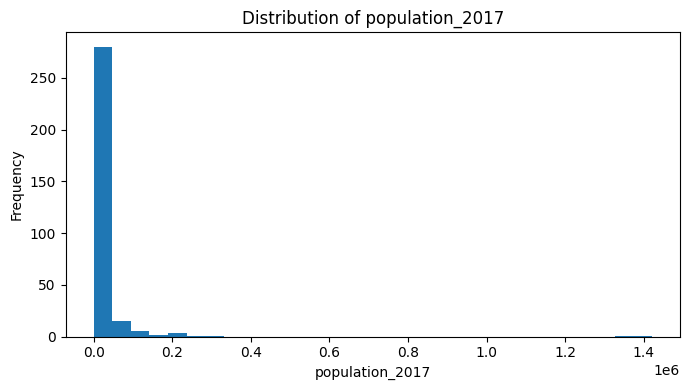

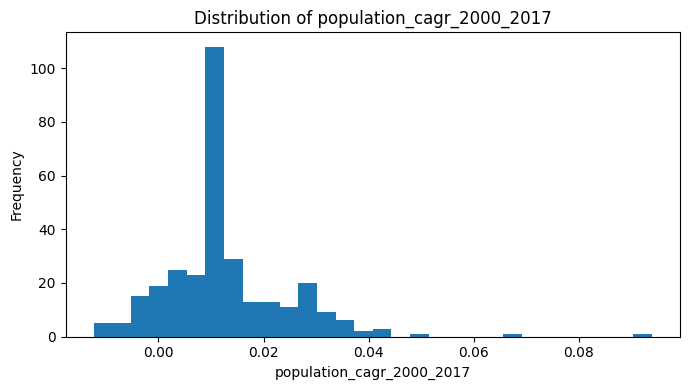

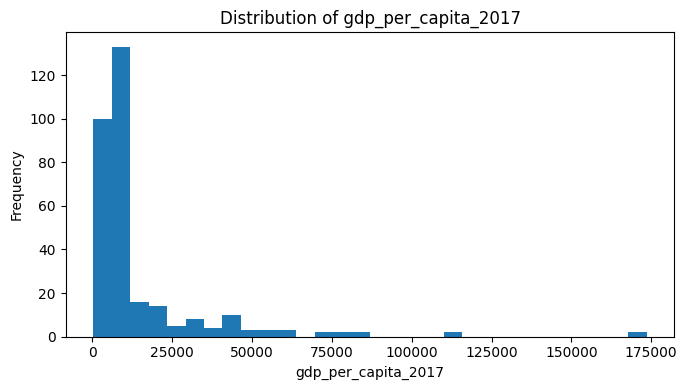

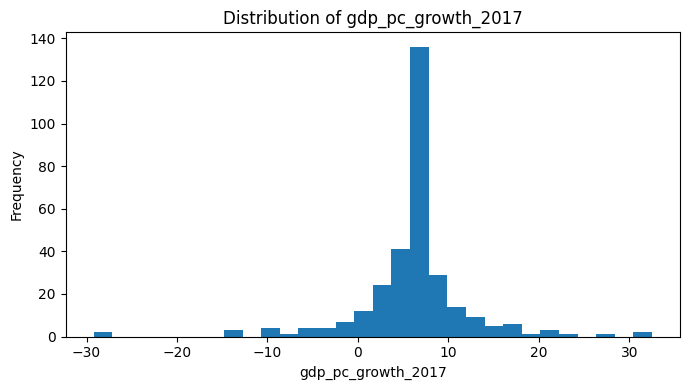

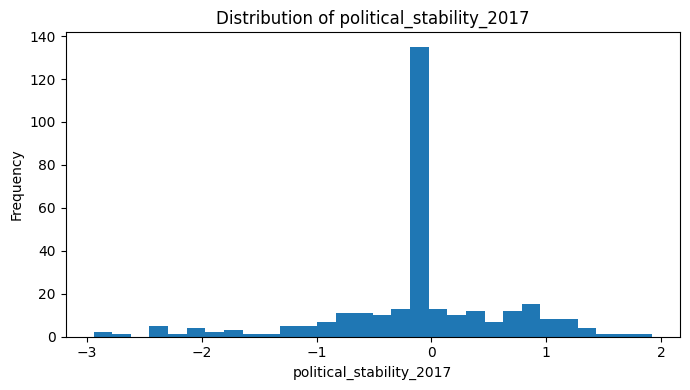

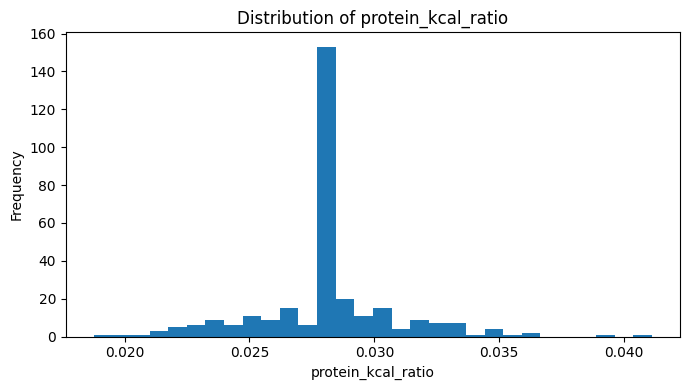

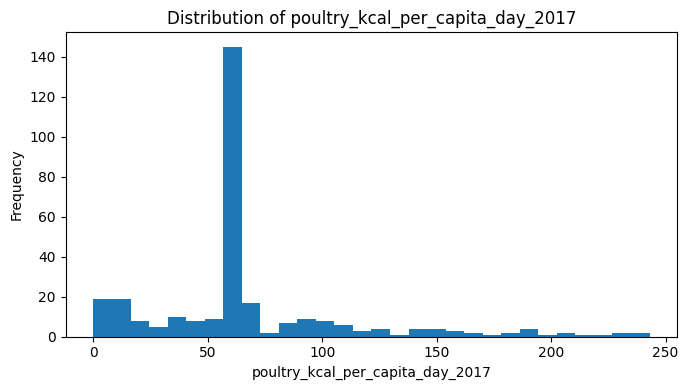

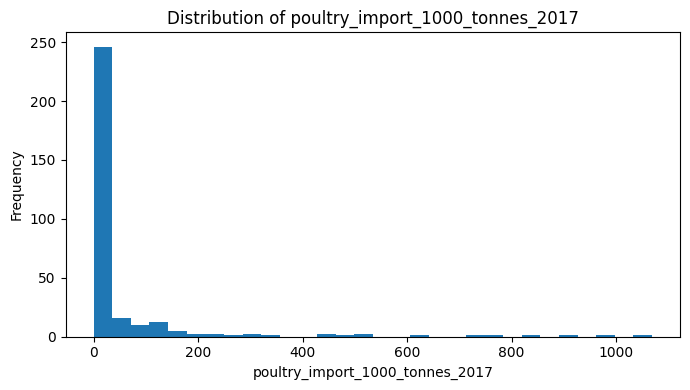

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

Pour comprendre :

- La forme de la distribution

- Est-elle normale ?

- Est-elle asymétrique ?

- Présente-t-elle une longue queue ?

</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Boxplots</h3>
</div>


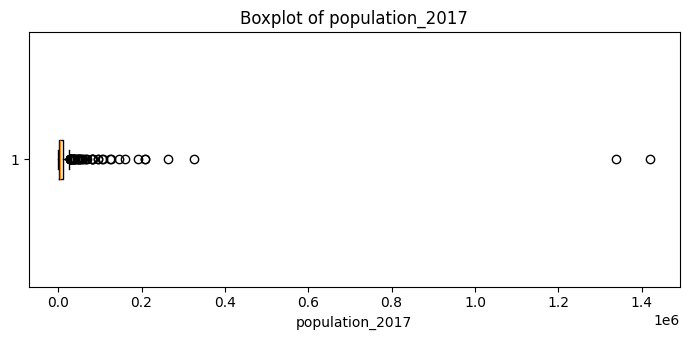

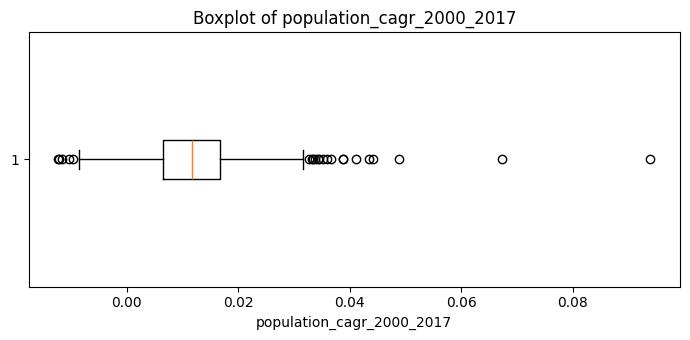

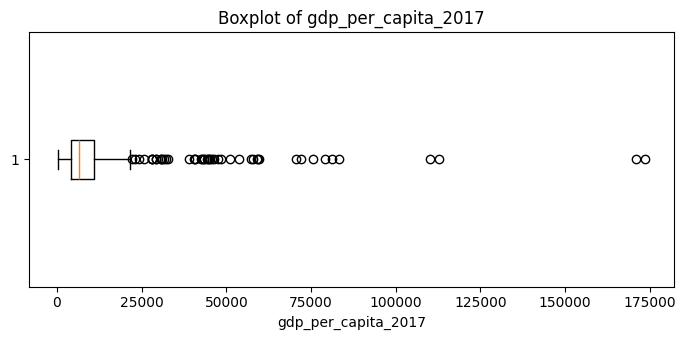

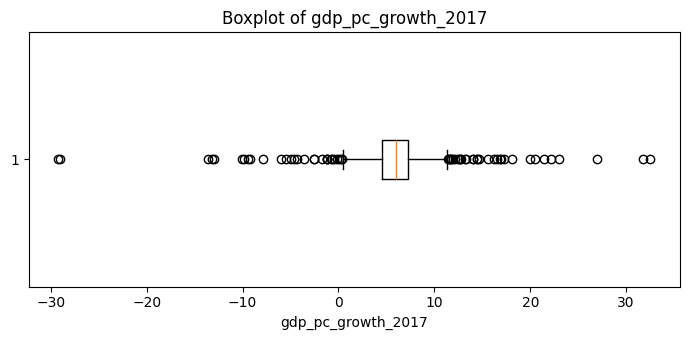

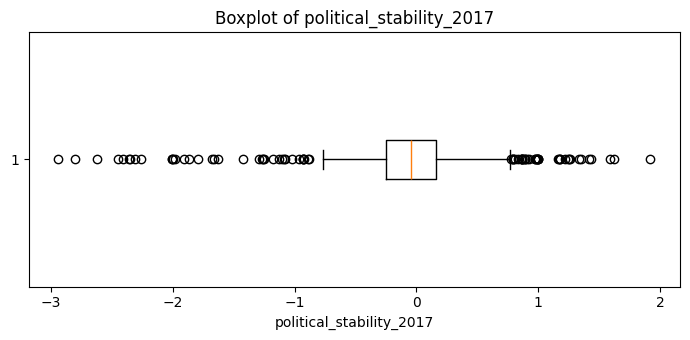

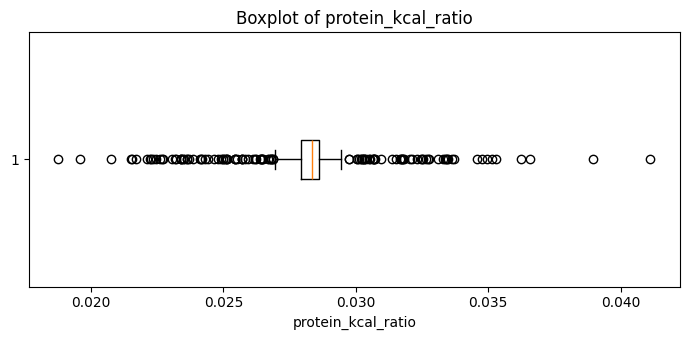

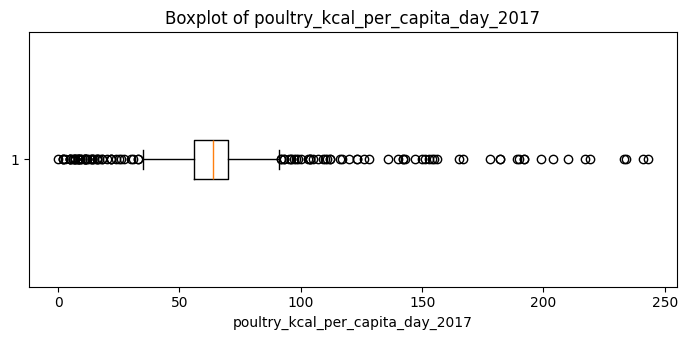

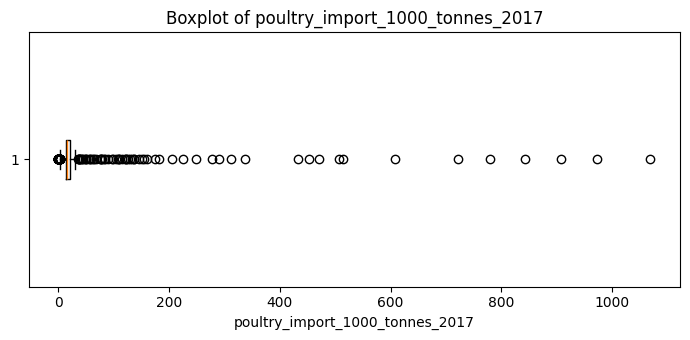

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(7, 3.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

- Pour révéler visuellement les valeurs extrêmes

</div>

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Correlation matrix</h3>
</div>



In [8]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
population_2017,1.000,-0.006,-0.032,0.046,-0.106,-0.005,-0.049,0.187
population_cagr_2000_2017,-0.006,1.000,-0.045,-0.188,-0.151,-0.238,-0.201,-0.030
gdp_per_capita_2017,-0.032,-0.045,1.000,-0.072,0.257,0.314,0.249,0.149
gdp_pc_growth_2017,0.046,-0.188,-0.072,1.000,0.041,0.037,0.018,0.014
political_stability_2017,-0.106,-0.151,0.257,0.041,1.000,0.161,0.210,0.015
protein_kcal_ratio,-0.005,-0.238,0.314,0.037,0.161,1.000,0.412,0.176
poultry_kcal_per_capita_day_2017,-0.049,-0.201,0.249,0.018,0.210,0.412,1.000,0.197
poultry_import_1000_tonnes_2017,0.187,-0.030,0.149,0.014,0.015,0.176,0.197,1.000


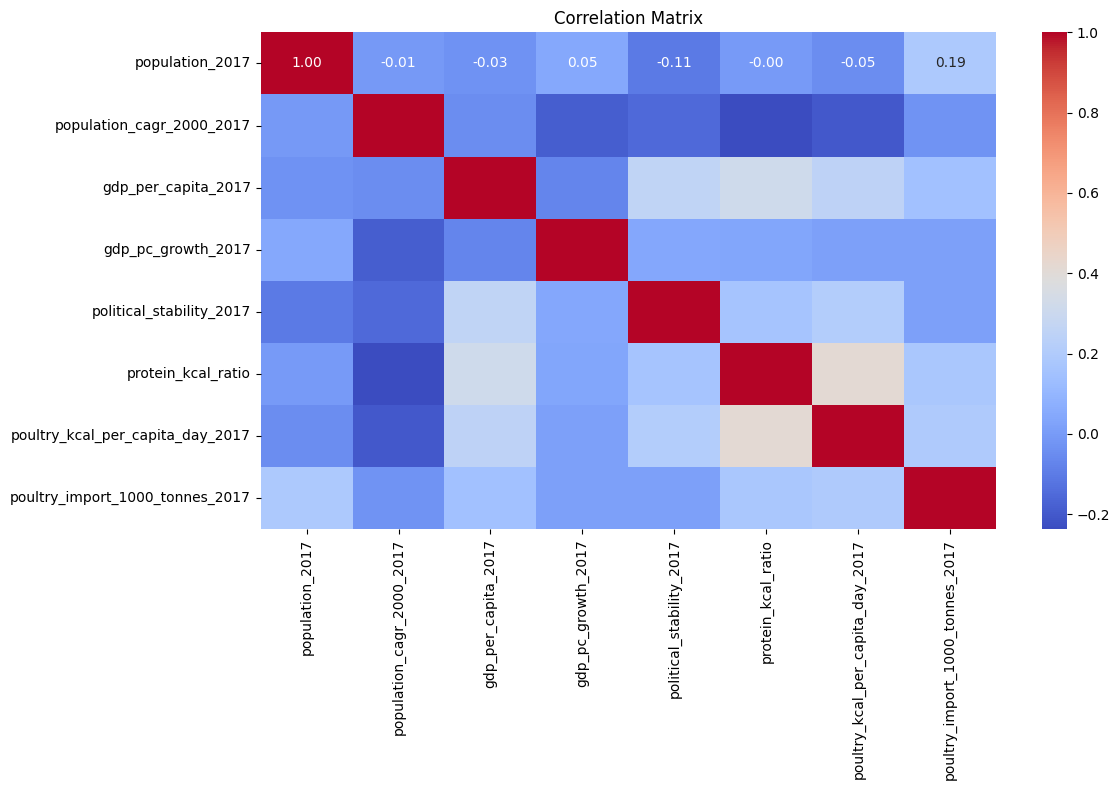

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">

Calculez la corrélation entre chaque paire de variables.

Déterminez :

- Y a-t-il des variables dupliquées ?

- Les nouvelles variables apportent-elles une information supplémentaire ?

- Quelles sont les relations logiques entre les différentes dimensions ?

</div>






<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Les liaisons absolues les plus fortes</h3>
</div>



In [10]:
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs.head(30)

protein_kcal_ratio                poultry_kcal_per_capita_day_2017   0.412
poultry_kcal_per_capita_day_2017  protein_kcal_ratio                 0.412
protein_kcal_ratio                gdp_per_capita_2017                0.314
gdp_per_capita_2017               protein_kcal_ratio                 0.314
political_stability_2017          gdp_per_capita_2017                0.257
gdp_per_capita_2017               political_stability_2017           0.257
poultry_kcal_per_capita_day_2017  gdp_per_capita_2017                0.249
gdp_per_capita_2017               poultry_kcal_per_capita_day_2017   0.249
protein_kcal_ratio                population_cagr_2000_2017          0.238
population_cagr_2000_2017         protein_kcal_ratio                 0.238
political_stability_2017          poultry_kcal_per_capita_day_2017   0.210
poultry_kcal_per_capita_day_2017  political_stability_2017           0.210
population_cagr_2000_2017         poultry_kcal_per_capita_day_2017   0.201
poultry_kcal_per_capita_d

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Nombre de valeurs aberrantes par le biais de IQR</h3>
</div>


In [11]:
def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = pd.Series({col: count_outliers_iqr(df[col]) for col in numeric_cols})
outlier_counts.sort_values(ascending=False)

protein_kcal_ratio                  119
poultry_kcal_per_capita_day_2017    112
poultry_import_1000_tonnes_2017     111
political_stability_2017             76
gdp_pc_growth_2017                   62
population_2017                      49
gdp_per_capita_2017                  48
population_cagr_2000_2017            22
dtype: int64

<div style="border: 2px solid #940D0D;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">Pays présentant les valeurs les plus élevées et les plus faibles pour chaque variable</h3>
</div>



In [12]:
for col in numeric_cols:
    print("=" * 80)
    print(f"Top 5 highest values for {col}")
    display(df[["country", col]].sort_values(by=col, ascending=False).head(5))

    print(f"Top 5 lowest values for {col}")
    display(df[["country", col]].sort_values(by=col, ascending=True).head(5))

Top 5 highest values for population_2017


,country,population_2017
45,China,"1,421,021.791"
113,India,"1,338,676.785"
283,United States,"325,084.756"
114,Indonesia,"264,650.963"
190,Pakistan,"207,906.209"


Top 5 lowest values for population_2017


,country,population_2017
226,Saint-Siège,0.793
268,Tokélaou,1.300
182,Nioué,1.609
300,Îles Falkland (Malvinas),3.068
168,Montserrat,4.984


Top 5 highest values for population_cagr_2000_2017


...

,country,poultry_kcal_per_capita_day_2017
81,Ethiopia,0.000
262,Tchad,2.000
181,Nigeria,2.000
128,Kenya,2.000
180,Niger,3.000


Top 5 highest values for poultry_import_1000_tonnes_2017


,country,poultry_import_1000_tonnes_2017
124,Japan,"1,069.000"
161,Mexico,972.000
51,Chine - RAS de Hong-Kong,907.000
90,Germany,842.000
209,Royaume-Uni de Grande-Bretagne et d'Irlande du...,779.000


Top 5 lowest values for poultry_import_1000_tonnes_2017


,country,poultry_import_1000_tonnes_2017
181,Nigeria,0.000
119,Israel,0.000
113,India,0.000
17,Bangladesh,0.000
40,Cameroon,0.000


<div style="border-left: 6px solid #940D0D; background-color: #f9fafc; padding: 20px; border-radius: 10px;">


Présentation :

- Top 5 des pays

- Bottom 5 des pays

Pour comprendre leur profil :

- Pays les plus peuplés

- Principaux importateurs

- Pays au revenu le plus élevé

- Pays les plus stables

</div>


In [13]:
df_eda = df.copy()

df_eda["log_population_2017"] = np.log1p(df_eda["population_2017"])
df_eda["log_gdp_per_capita_2017"] = np.log1p(df_eda["gdp_per_capita_2017"])
df_eda["log_poultry_import_1000_tonnes_2017"] = np.log1p(df_eda["poultry_import_1000_tonnes_2017"])

display(df_eda[[
    "country",
    "log_population_2017",
    "log_gdp_per_capita_2017",
    "log_poultry_import_1000_tonnes_2017"
]].head())

,country,log_population_2017,log_gdp_per_capita_2017,log_poultry_import_1000_tonnes_2017
0,Afghanistan,10.499,6.275,3.401
1,Albania,7.967,8.417,3.664
2,Algeria,10.631,8.327,1.099
3,American Samoa,8.603,8.772,2.833
4,Andorra,4.357,10.612,2.833


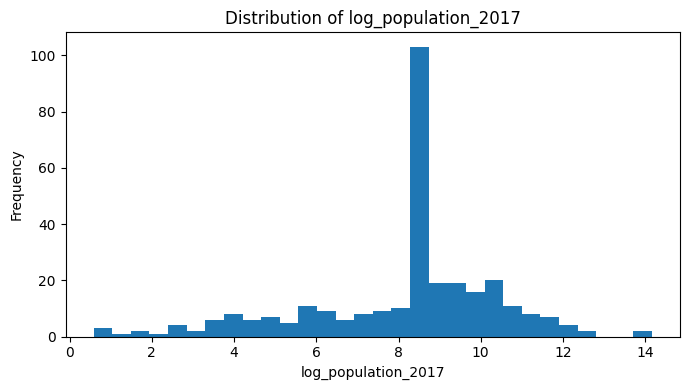

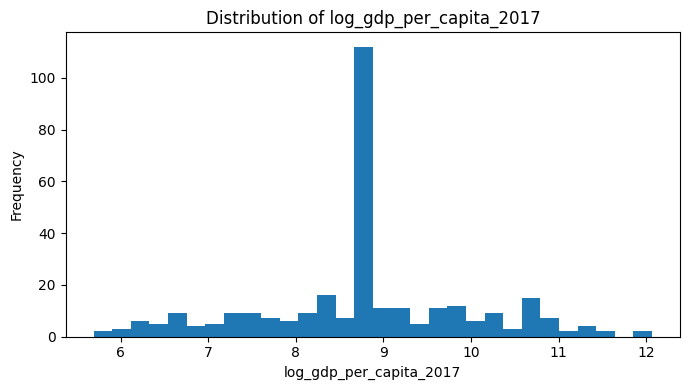

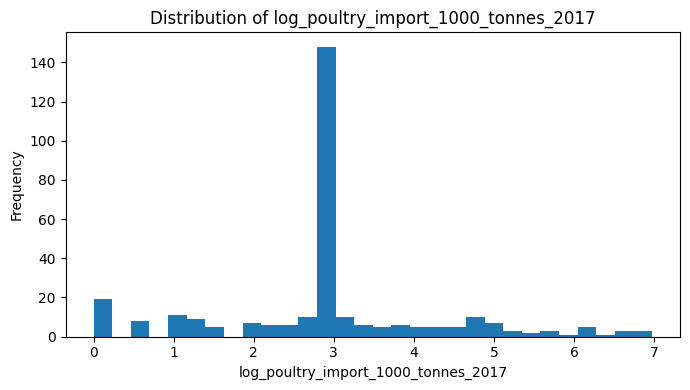

In [14]:
log_cols = [
    "log_population_2017",
    "log_gdp_per_capita_2017",
    "log_poultry_import_1000_tonnes_2017"
]

for col in log_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df_eda[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [17]:
poultry_focus_cols = [
    "protein_kcal_ratio",
    "poultry_kcal_per_capita_day_2017",
    "poultry_import_1000_tonnes_2017"
]

df[poultry_focus_cols].corr()

,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
protein_kcal_ratio,1.000,0.412,0.176
poultry_kcal_per_capita_day_2017,0.412,1.000,0.197
poultry_import_1000_tonnes_2017,0.176,0.197,1.000


In [18]:
poultry_focus_cols = [
    "protein_kcal_ratio",
    "poultry_kcal_per_capita_day_2017",
    "poultry_import_1000_tonnes_2017"
]

df[poultry_focus_cols].corr()

,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
protein_kcal_ratio,1.000,0.412,0.176
poultry_kcal_per_capita_day_2017,0.412,1.000,0.197
poultry_import_1000_tonnes_2017,0.176,0.197,1.000


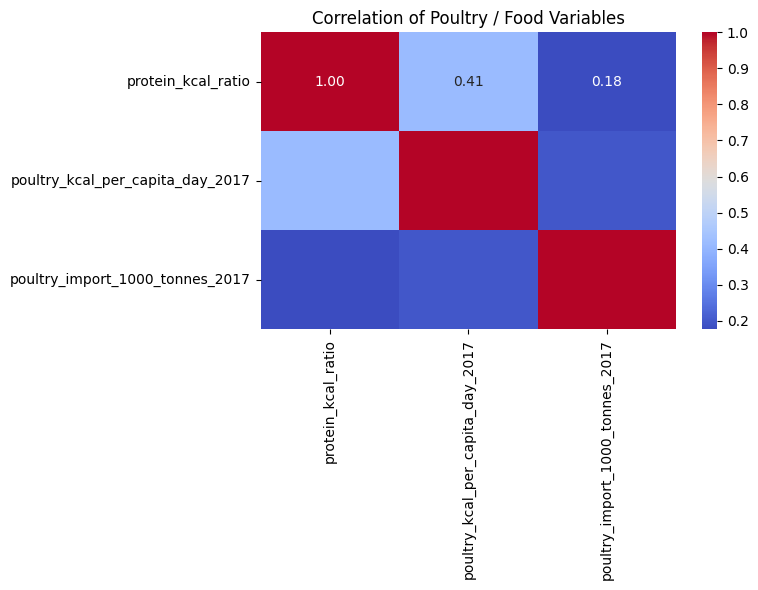

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[poultry_focus_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Poultry / Food Variables")
plt.tight_layout()
plt.show()

In [20]:
candidate_vars = [
    "population_2017",
    "population_cagr_2000_2017",
    "gdp_per_capita_2017",
    "gdp_pc_growth_2017",
    "political_stability_2017",
    "protein_kcal_ratio",
    "poultry_kcal_per_capita_day_2017",
    "poultry_import_1000_tonnes_2017"
]

candidate_vars

['population_2017',
 'population_cagr_2000_2017',
 'gdp_per_capita_2017',
 'gdp_pc_growth_2017',
 'political_stability_2017',
 'protein_kcal_ratio',
 'poultry_kcal_per_capita_day_2017',
 'poultry_import_1000_tonnes_2017']

In [21]:
candidate_corr = df[candidate_vars].corr()
candidate_corr

,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
population_2017,1.000,-0.006,-0.032,0.046,-0.106,-0.005,-0.049,0.187
population_cagr_2000_2017,-0.006,1.000,-0.045,-0.188,-0.151,-0.238,-0.201,-0.030
gdp_per_capita_2017,-0.032,-0.045,1.000,-0.072,0.257,0.314,0.249,0.149
gdp_pc_growth_2017,0.046,-0.188,-0.072,1.000,0.041,0.037,0.018,0.014
political_stability_2017,-0.106,-0.151,0.257,0.041,1.000,0.161,0.210,0.015
protein_kcal_ratio,-0.005,-0.238,0.314,0.037,0.161,1.000,0.412,0.176
poultry_kcal_per_capita_day_2017,-0.049,-0.201,0.249,0.018,0.210,0.412,1.000,0.197
poultry_import_1000_tonnes_2017,0.187,-0.030,0.149,0.014,0.015,0.176,0.197,1.000


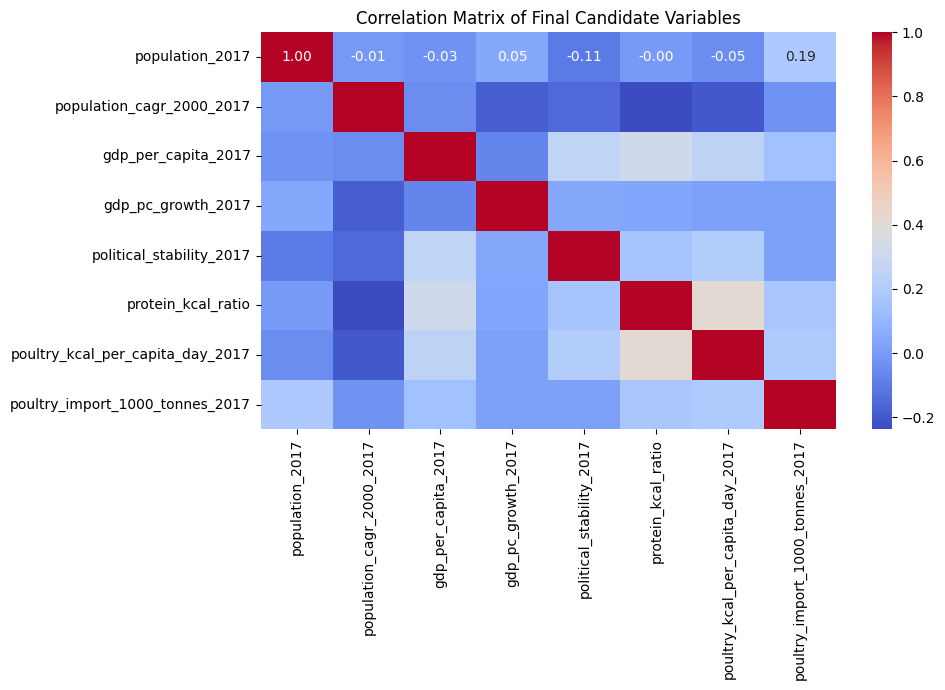

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(candidate_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Final Candidate Variables")
plt.tight_layout()
plt.show()

In [23]:
df_final_model = df[["country"] + candidate_vars].copy()

print(df_final_model.shape)
display(df_final_model.head())

(309, 9)


,country,population_2017,population_cagr_2000_2017,gdp_per_capita_2017,gdp_pc_growth_2017,political_stability_2017,protein_kcal_ratio,poultry_kcal_per_capita_day_2017,poultry_import_1000_tonnes_2017
0,Afghanistan,"36,296.113",0.033,530.150,1.902,-2.800,0.027,5.000,29.000
1,Albania,"2,884.169",-0.005,"4,521.752",9.831,0.380,0.035,85.000,38.000
2,Algeria,"41,389.189",0.017,"4,134.936",4.228,-0.920,0.028,22.000,2.000
3,American Samoa,"5,447.900",0.012,"6,450.320",6.002,1.220,0.028,64.000,16.000
4,Andorra,77.001,0.010,"40,632.206",1.825,1.420,0.028,64.000,16.000


In [24]:
print("Missing values:")
display(df_final_model.isna().sum())

print("Duplicated countries:", df_final_model["country"].duplicated().sum())

Missing values:


country                             0
population_2017                     0
population_cagr_2000_2017           0
gdp_per_capita_2017                 0
gdp_pc_growth_2017                  0
political_stability_2017            0
protein_kcal_ratio                  0
poultry_kcal_per_capita_day_2017    0
poultry_import_1000_tonnes_2017     0
dtype: int64

Duplicated countries: 0


In [25]:
df_final_model.drop(columns="country").describe().T

,count,mean,std,min,25%,50%,75%,max
population_2017,309.000,"25,674.451","115,747.467",0.793,"1,384.059","5,447.900","11,339.254","1,421,021.791"
population_cagr_2000_2017,309.000,0.013,0.012,-0.012,0.006,0.012,0.017,0.094
gdp_per_capita_2017,309.000,"13,576.326","21,651.322",295.621,"4,041.995","6,450.320","11,020.663","173,611.815"
gdp_pc_growth_2017,309.000,5.909,6.170,-29.218,4.514,6.002,7.249,32.525
political_stability_2017,309.000,-0.093,0.766,-2.940,-0.250,-0.045,0.160,1.920
protein_kcal_ratio,309.000,0.028,0.003,0.019,0.028,0.028,0.029,0.041
poultry_kcal_per_capita_day_2017,309.000,69.877,45.437,0.000,56.000,64.000,70.000,243.000
poultry_import_1000_tonnes_2017,309.000,56.453,143.046,0.000,14.000,16.000,21.000,"1,069.000"


In [26]:
output_dir = Path("../data_clean")
output_dir.mkdir(parents=True, exist_ok=True)

df_final_model.to_csv(output_dir / "dataset_2017_final_model_for_pca_v3.csv", index=False)

print("Saved file:")
print("-", output_dir / "dataset_2017_final_model_for_pca_v3.csv")

Saved file:
- ../data_clean/dataset_2017_final_model_for_pca_v3.csv
